# P640 Regression

### EDA + DATA PREPROCESSING

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import math

In [2]:
# load
df=pd.read_csv('solarpowergeneration (2).csv')
df.head()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069


In [3]:
## shape
df.shape

(2920, 10)

In [4]:
# columns
df.columns

Index(['distance-to-solar-noon', 'temperature', 'wind-direction', 'wind-speed',
       'sky-cover', 'visibility', 'humidity', 'average-wind-speed-(period)',
       'average-pressure-(period)', 'power-generated'],
      dtype='object')

In [5]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   distance-to-solar-noon       2920 non-null   float64
 1   temperature                  2920 non-null   int64  
 2   wind-direction               2920 non-null   int64  
 3   wind-speed                   2920 non-null   float64
 4   sky-cover                    2920 non-null   int64  
 5   visibility                   2920 non-null   float64
 6   humidity                     2920 non-null   int64  
 7   average-wind-speed-(period)  2919 non-null   float64
 8   average-pressure-(period)    2920 non-null   float64
 9   power-generated              2920 non-null   int64  
dtypes: float64(5), int64(5)
memory usage: 228.3 KB


In [6]:
df.describe()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
count,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2919.000000,2920.000000,2920.000000
mean,0.503294,58.468493,24.953425,10.096986,1.987671,9.557705,73.513699,10.129154,30.017760,6979.846233
std,0.298024,6.841200,6.915178,4.838185,1.411978,1.383884,15.077139,7.261547,0.142006,10312.336413
min,0.050401,42.000000,1.000000,1.100000,0.000000,0.000000,14.000000,0.000000,29.480000,0.000000
25%,0.243714,53.000000,25.000000,6.600000,1.000000,10.000000,65.000000,5.000000,29.920000,0.000000
50%,0.478957,59.000000,27.000000,10.000000,2.000000,10.000000,77.000000,9.000000,30.000000,404.000000
75%,0.739528,63.000000,29.000000,13.100000,3.000000,10.000000,84.000000,15.000000,30.110000,12723.500000
max,1.141361,78.000000,36.000000,26.600000,4.000000,10.000000,100.000000,40.000000,30.530000,36580.000000


In [7]:
#missing values
df.isnull().sum()

distance-to-solar-noon         0
temperature                    0
wind-direction                 0
wind-speed                     0
sky-cover                      0
visibility                     0
humidity                       0
average-wind-speed-(period)    1
average-pressure-(period)      0
power-generated                0
dtype: int64

In [8]:
## drop
df.dropna(inplace=True)
df.isnull().sum()

distance-to-solar-noon         0
temperature                    0
wind-direction                 0
wind-speed                     0
sky-cover                      0
visibility                     0
humidity                       0
average-wind-speed-(period)    0
average-pressure-(period)      0
power-generated                0
dtype: int64

In [9]:
## duplicates
df.duplicated().sum()

np.int64(0)

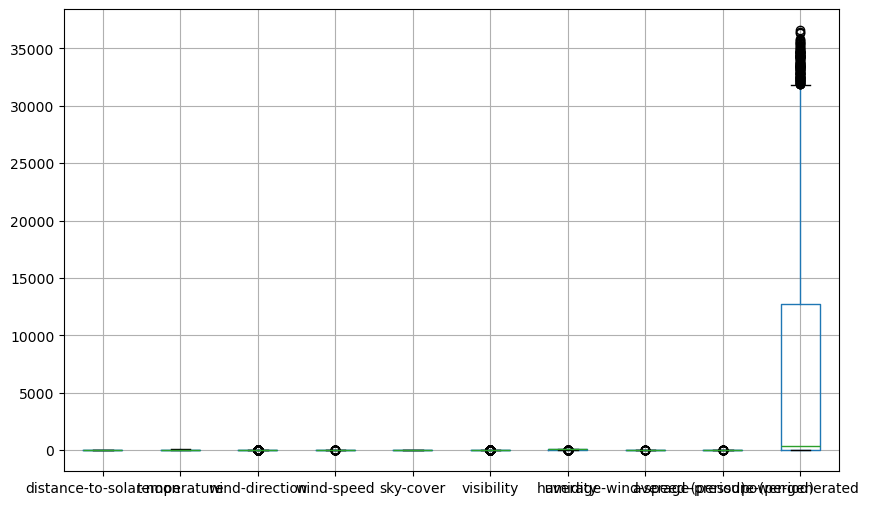

In [10]:
## outliers
plt.figure(figsize=(10,6))
df.boxplot()
plt.show()

In [11]:
### outlier capping
def outlier_capping(df,column):
        Q1=df[column].quantile(0.25)
        Q3=df[column].quantile(0.75)
        IQR=Q3-Q1
        Lower_Extreme=Q1-1.5*IQR
        Upper_Extreme=Q3+1.5*IQR
        df[column]=df[column].apply(lambda x: Lower_Extreme if x<Lower_Extreme else Upper_Extreme if x> Upper_Extreme else x)
for col in df.drop(columns=['power-generated']).columns:
        outlier_capping(df,col)

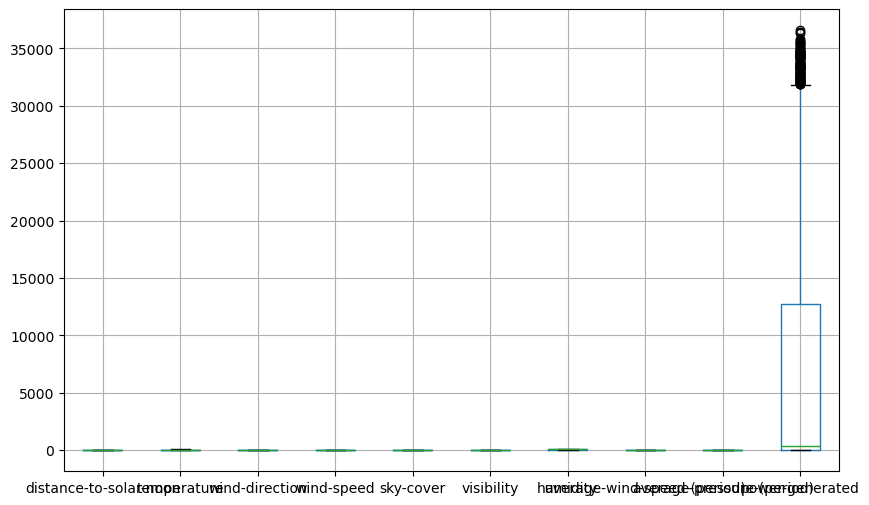

In [12]:
plt.figure(figsize=(10,6))
df.boxplot()
plt.show()

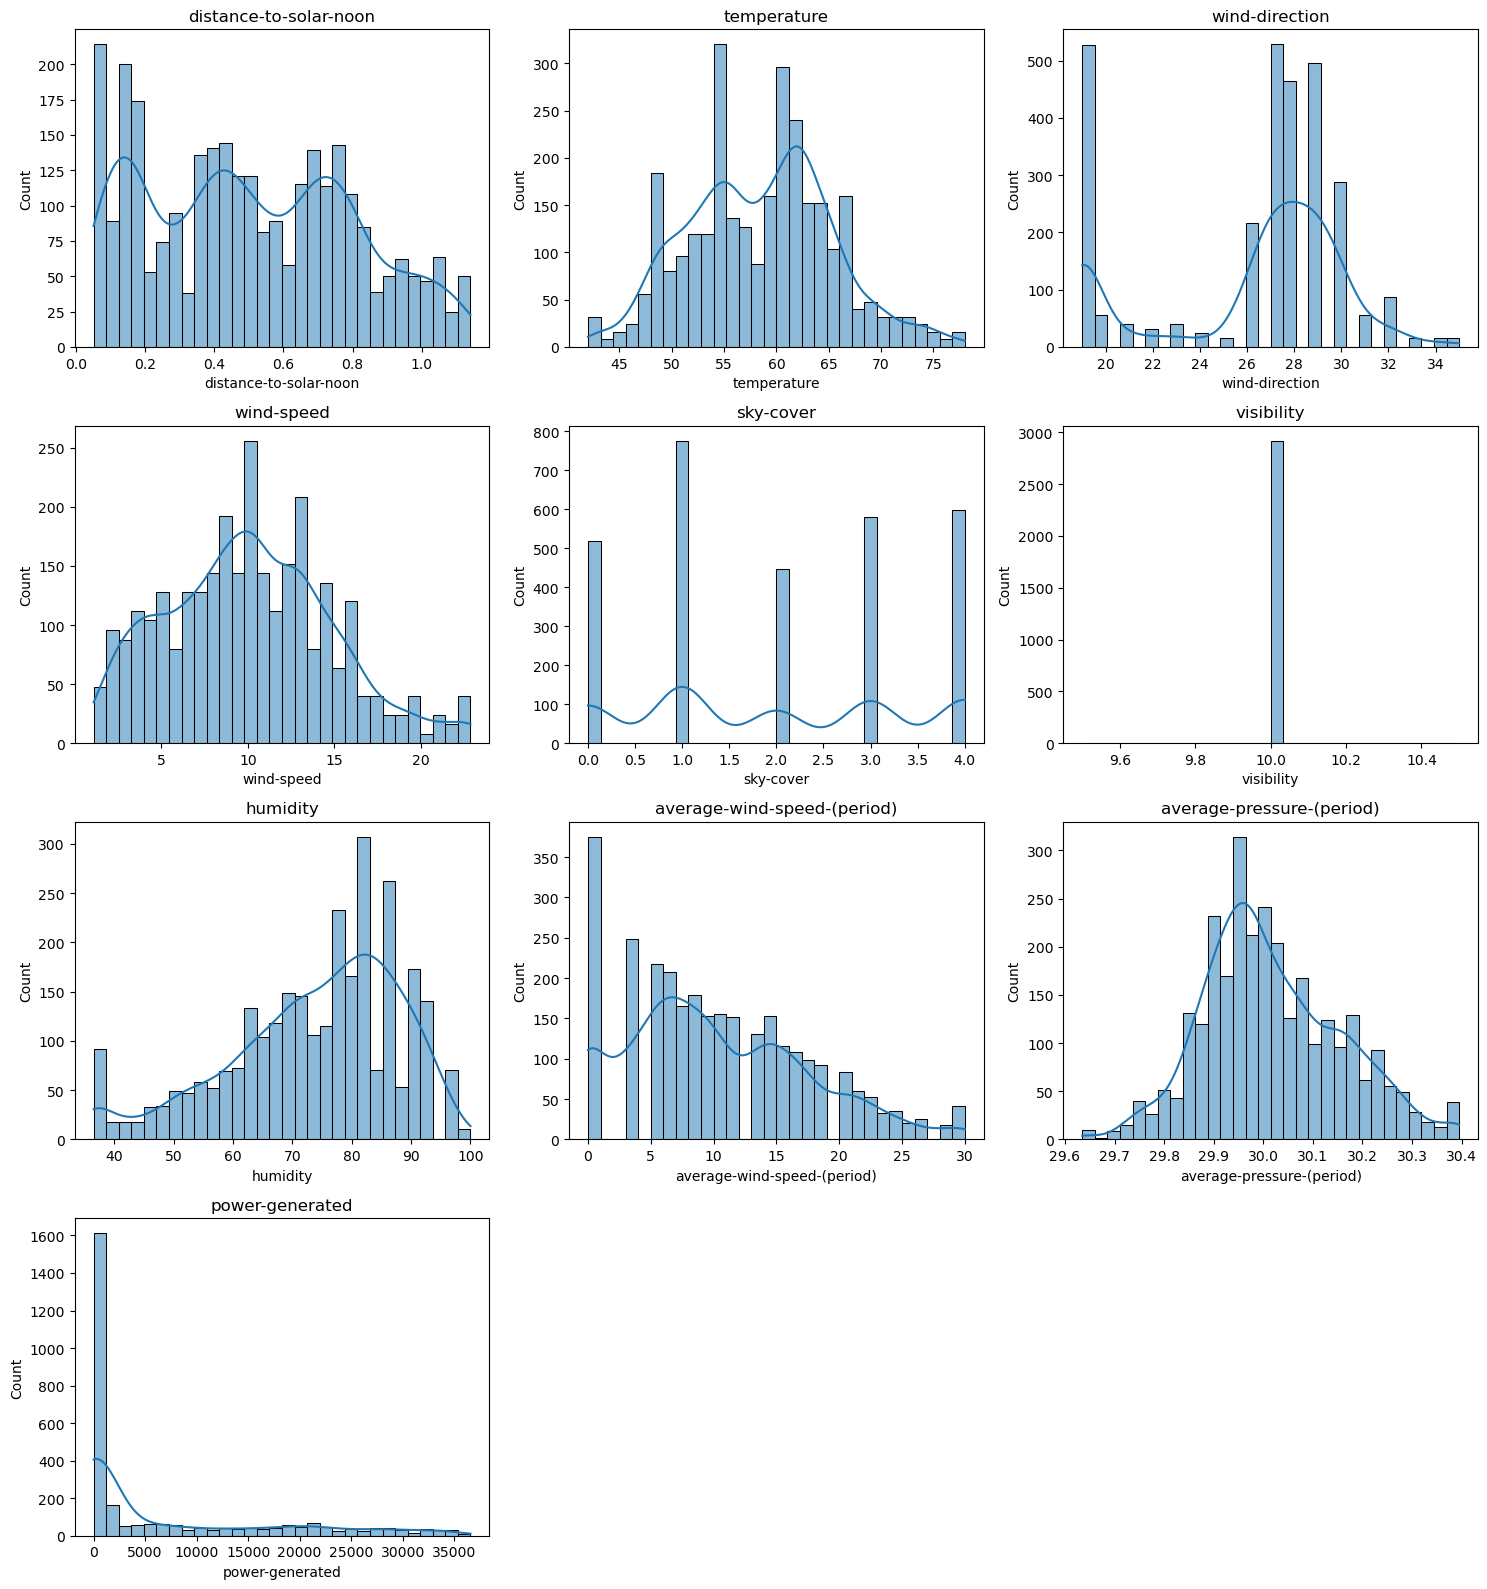

In [16]:
#feature distribution
cols = df.columns
r = math.ceil(len(cols) / 3)
plt.figure(figsize=(15, 4*r))
for i, col in enumerate(cols, 1):
    plt.subplot(r, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
df.drop(columns=['visibility'],inplace=True)

In [ ]:
## correlation
corr=df.corr()
sns.heatmap(corr,annot=True)
plt.show()

### Feature engineering

In [ ]:
df['wind_dir_sin'] = np.sin(np.deg2rad(df['wind-direction']))
df['wind_dir_cos'] = np.cos(np.deg2rad(df['wind-direction']))

In [ ]:
df.drop(columns=['wind-direction'], inplace=True)

In [ ]:
df['wind_speed_mean'] = (df['wind-speed'] + df['average-wind-speed-(period)']) / 2
df.head()

In [ ]:
target=df['power-generated']
features=df.drop(columns=['power-generated'])

In [ ]:
#train_test_split
x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=0.2,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

In [ ]:
## scaling
std_sca=StandardScaler()
x_train=std_sca.fit_transform(x_train)
x_test=std_sca.transform(x_test)